In [1]:
"""
Clasificador de dígitos con PyTorch (MNIST)
Objetivo: Construir una red neuronal completamente conectada (MLP) que reciba una imagen de 28×28 píxeles y prediga qué número (0-9) aparece en ella.
Imagen 28x28
        │
        ▼
Flatten
        │
784 números
        │
        ▼
Linear(784 → 128)
        │
ReLU
        │
        ▼
Linear(128 → 64)
        │
ReLU
        │
        ▼
Linear(64 → 10)
"""
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch.optim as optim
from torchvision import datasets

training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

# Entrenamiento

In [4]:
# Definición del modelo ============================================================================================================
model = nn.Sequential(
    nn.Flatten(), # Convierte cada imagen de (1,28,28) a un vector de 784 valores

    nn.Linear(784, 128), # Primera capa totalmente conectada (784 -> 128 neuronas)
    nn.ReLU(), # Función de activación no lineal

    nn.Linear(128, 64), # Segunda capa totalmente conectada (128 -> 64 neuronas)
    nn.ReLU(), # Nueva activacion

    nn.Linear(64, 10) # Capa de salida: un logit para cada uno de los 10 dígitos (0-9)
)

# Configuración del entrenamiento ==================================================================================================
criterion = nn.CrossEntropyLoss() # Función de pérdida para clasificación multiclase. Recibe los logits del modelo y las etiquetas reales.
optimizer = optim.SGD(model.parameters(), lr=0.01) # Algoritmo encargado de actualizar pesos y bias utilizando descenso por gradiente.
dataloader = torch.utils.data.DataLoader(training_data, batch_size=64, shuffle=True) # Divide el dataset en lotes de 64 imágenes y los mezcla
                                                                                     # en cada época para evitar aprender siempre el mismo orden.

# Entrenamiento ====================================================================================================================
losses = [] # Guarda el loss de cada batch para poder graficarlo luego.
for epoch in range(10):
  correct = 0 # Cantidad de imágenes clasificadas correctamente.
  total = 0 # Cantidad total de imágenes procesadas.
  total_loss = 0 # Suma del loss de todos los batches de la época.

  for images, labels in dataloader:
    optimizer.zero_grad() # Reinicia los gradientes acumulados del paso anterior.
    outputs = model(images) # Forward: obtiene los logits del modelo. Shape 64x10
    loss = criterion(outputs, labels) # Calcula la pérdida comparando logits vs etiquetas reales.
    losses.append(loss.item()) # Guarda el valor del loss para visualizar su evolución.
    loss.backward() # Backpropagation: Calcula automáticamente todos los gradientes.
    optimizer.step() # Actualiza pesos y bias utilizando esos gradientes.

    total_loss += loss.item() # Acumula el loss de este batch.
    predictions = outputs.argmax(dim=1) # Elige el logit más grande de cada imagen. Esa será la clase predicha.
    correct += (predictions == labels).sum().item() # Cuenta cuántas imágenes fueron clasificadas correctamente.
    total += labels.size(0) # Acumula la cantidad total de imágenes vistas.

  # Métricas de la época
  avg_loss = total_loss / len(dataloader) # Loss promedio considerando todos los batches.
  accuracy = correct / total # Porcentaje de aciertos sobre todo el dataset.
  print(f"Época {epoch+1}: Loss = {avg_loss:.4f}")
  print(f"Época {epoch+1}: Accuracy = {accuracy*100:.2f}%")

Época 1: Loss = 1.7192
Época 1: Accuracy = 55.02%
Época 2: Loss = 0.5646
Época 2: Accuracy = 85.10%
Época 3: Loss = 0.4018
Época 3: Accuracy = 88.76%
Época 4: Loss = 0.3499
Época 4: Accuracy = 90.03%
Época 5: Loss = 0.3182
Época 5: Accuracy = 90.86%
Época 6: Loss = 0.2936
Época 6: Accuracy = 91.57%
Época 7: Loss = 0.2736
Época 7: Accuracy = 92.11%
Época 8: Loss = 0.2556
Época 8: Accuracy = 92.66%
Época 9: Loss = 0.2397
Época 9: Accuracy = 93.09%
Época 10: Loss = 0.2255
Época 10: Accuracy = 93.55%


Tipo de dato devuelto por el dataset: <class 'tuple'>
Tipo de la imagen: <class 'torch.Tensor'> (Dtype: torch.float32)
Forma (Shape) del tensor de la imagen: torch.Size([1, 28, 28])
Tipo de la etiqueta: <class 'int'> -> Valor: 5


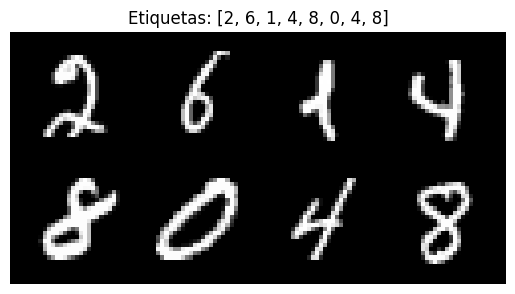

In [ ]:
"""
IGNORAR

import torchvision

# Obtener el primer elemento para analizar tipo, forma y etiqueta
imagen, etiqueta = training_data[0]
print(f"Tipo de dato devuelto por el dataset: {type(training_data[0])}")
print(f"Tipo de la imagen: {type(imagen)} (Dtype: {imagen.dtype})")
print(f"Forma (Shape) del tensor de la imagen: {imagen.shape}")
print(f"Tipo de la etiqueta: {type(etiqueta)} -> Valor: {etiqueta}")

# Configurar DataLoader para mostrar imágenes
dataloader = torch.utils.data.DataLoader(training_data, batch_size=8, shuffle=True)
imagenes_lote, etiquetas_lote = next(iter(dataloader))

# Mostrar la cuadrícula de imágenes
grid = torchvision.utils.make_grid(imagenes_lote, nrow=4)
# Permutar las dimensiones de (C, H, W) a (H, W, C) que es lo que espera matplotlib
plt.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
plt.title(f"Etiquetas: {etiquetas_lote.tolist()}")
plt.axis('off')
plt.show()
"""

# Evaluación del Modelo

In [167]:
model.eval() # Pone el modelo en modo de evaluación (desactiva dropout, batchnorm, etc.)

# Configuración de ejecución ==================================================================================================
dataloader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=True)

def evaluate_model(model, dataloader):
  for epoch in range(1):
    correct = 0
    total = 0

    with torch.no_grad(): # Desactiva el cálculo de gradientes para ahorrar memoria y computación.
      for images, labels in dataloader:
        outputs = model(images)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    # Métricas de la época
    accuracy = correct / total
    print(f"Época {epoch+1}: Accuracy = {accuracy*100:.2f}%")

    if len(dataloader) == 1:
      print(f"Imagen real: {labels[0].item()}")
      print(f"Imagen predicha: {predictions[0].item()}")
      print(f"Logits: {outputs[0].tolist()}")

      # Convierte logits en probabilidades usando softmax
      probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
      print("Probabilidades de predicción:")
      for i, prob in enumerate(probabilities):
          print(f"  Clase {i}: {prob.item()*100:.2f}%")

      # Muestra la imagen
      plt.figure(figsize=(2,2))
      plt.imshow(images[0].squeeze().cpu().numpy(), cmap='gray')
      plt.title(f"Real: {labels[0].item()}, Predicha: {predictions[0].item()}")
      plt.axis('off')
      plt.show()


evaluate_model(model, dataloader)

Época 1: Accuracy = 93.81%


Época 1: Accuracy = 100.00%
Imagen real: 2
Imagen predicha: 2
Logits: [-1.465160608291626, -10.069350242614746, 9.016448974609375, 3.5296285152435303, 2.0591537952423096, -5.638529300689697, -2.527791738510132, -1.0012128353118896, 1.000087022781372, 5.391193866729736]
Probabilidades de predicción:
  Clase 0: 0.00%
  Clase 1: 0.00%
  Clase 2: 96.89%
  Clase 3: 0.40%
  Clase 4: 0.09%
  Clase 5: 0.00%
  Clase 6: 0.00%
  Clase 7: 0.00%
  Clase 8: 0.03%
  Clase 9: 2.58%


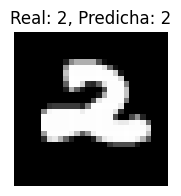

In [175]:
from random import randint
dtld = torch.utils.data.DataLoader([test_data[randint(1, len(test_data))]], batch_size=1, shuffle=True)
evaluate_model(model, dtld)

### Matriz de Confusión

Generar una matriz de confusión para visualizar qué dígitos el modelo está confundiendo y cuáles clasifica correctamente.

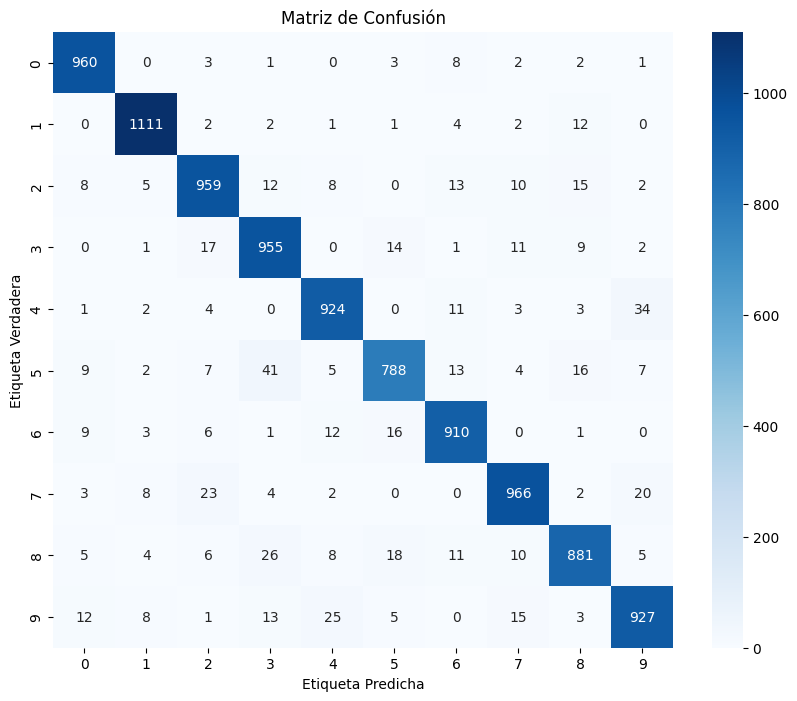

In [174]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Preparar listas para almacenar todas las etiquetas verdaderas y predichas
all_labels = []
all_predictions = []

# Asegurarse de que el modelo está en modo de evaluación
model.eval()

# Desactivar el cálculo de gradientes
with torch.no_grad():
    for images, labels in dataloader:
        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

# Calcular la matriz de confusión
cm = confusion_matrix(all_labels, all_predictions)

# Visualizar la matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.title('Matriz de Confusión')
plt.show()